# Day40
## Matplotlib 圖表範例解析
- 學習繪製不同類型的 Matplotlib 圖表

## 作業說明
- Day38-39 我們已經用散點圖為例，練習了 Matplotlib 畫板設置，
今天作業我們練習繪製不同類型的圖表
  - 折線圖
  - 長條圖
  - 直方圖
  - 圓餅圖
  - 矩陣圖

(Hint: 參考講義 Day40 內容)

In [1]:
import matplotlib.pyplot as plt
# 設置繪圖風格
plt.style.use("fivethirtyeight")

import numpy as np
np.random.seed(888)

%matplotlib inline

### 折線圖
- 請根據以下資料點繪製折線圖

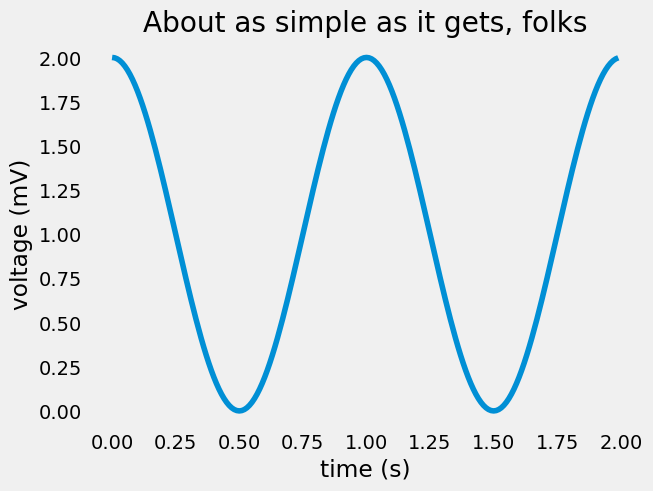

In [2]:
# 繪圖資料點
t = np.arange(0.0, 2.0, 0.01)
s = 1 + np.cos(2 * np.pi * t)
fig, ax = plt.subplots()
# 繪製資料點，x=t, y=s
ax.plot(t, s)
# 設置 x, y 軸標題及圖表標題
ax.set(xlabel='time (s)', ylabel='voltage (mV)',
       title='About as simple as it gets, folks')
# 添加網格線
ax.grid()
# 將圖表存至本地並命名為 test.png
fig.savefig("test.png")
# 展示圖表
plt.show()

### 垂直長條圖
- 請根據以下資料點繪製堆疊長條圖，呈現兩種顏色、不同組別的球數

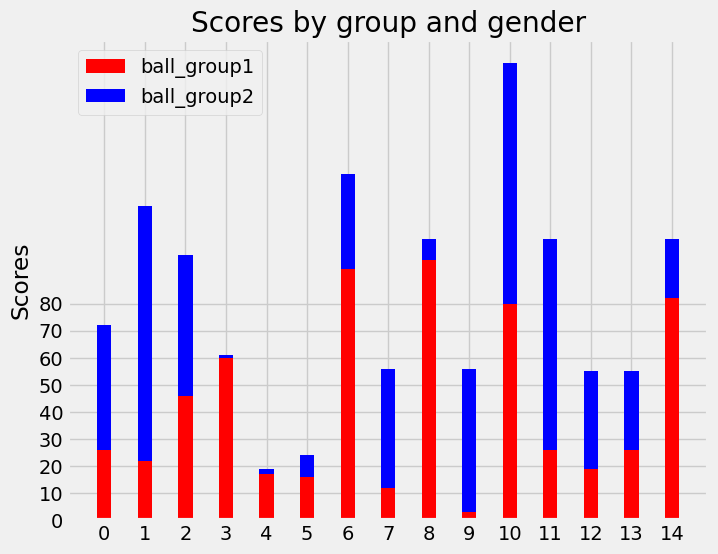

In [3]:
# 生成資料點
max_value, N, barWidth = 100, 15, 0.3
ball_group1 = np.random.randint(max_value, size=15)
ball_group2 = np.random.randint(max_value, size=15)
x_pos = np.arange(N)

barWidth = 0.35
# 創建畫板
fig = plt.figure()
# 指定位置創建子圖
ax = fig.add_axes([0,0,1,1])
# 繪製長條圖，x=x_pos, y=menMeans, barWith 指定長條寬度, color 指定顏色
ax.bar(x_pos, ball_group1, barWidth, color='r')
# 繪製長條圖，x=x_pos, y=womenMeans, bottom 設定圖表為堆疊形式
ax.bar(x_pos, ball_group2, barWidth, bottom=ball_group1, color='b')
# 設置 y 軸標題 及 圖表標題
ax.set_ylabel('Scores')
ax.set_title('Scores by group and gender')
# 設置 y 軸座標刻度位置
ax.set_xticks(np.arange(0, N, 1))
ax.set_yticks(np.arange(0, 81, 10))
# 設置圖例內容
ax.legend(labels=['ball_group1', 'ball_group2'])
plt.show()


### 直方圖
- 請根據以下資料點，繪製直方圖


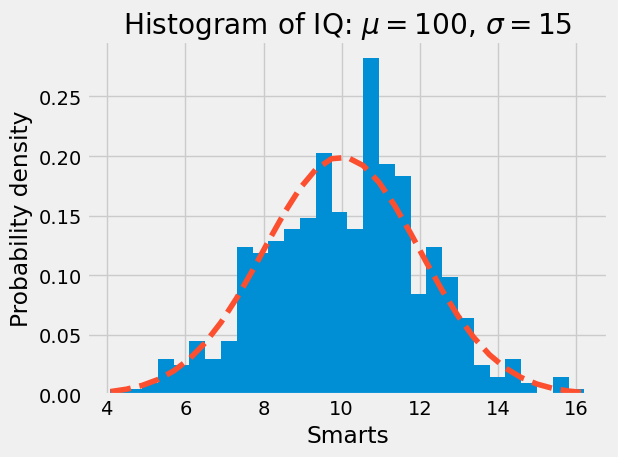

In [6]:
# 設置 x, y 軸標題及圖表標題
import numpy as np
import matplotlib.pyplot as plt

# 生成資料點
mean = 10
std = 2
x = mean + std * np.random.randn(500)
num_bins = 30

fig, ax = plt.subplots()
# 繪製直方圖，x 指定資料點, num_bins 指定切分範圍數, density 指定是否換算為機率密度函數
n, bins, patches = ax.hist(x, num_bins, density=True)
# 繪製常態分佈曲線
y = ((1 / (np.sqrt(2 * np.pi) * std)) *
     np.exp(-0.5 * (1 / std * (bins - mean))**2))
# x=bins 是之前直方圖切分的 x 位置, y=y 是經由上一步常態分佈公式計算的數值
ax.plot(bins, y, '--')
# 設置 x, y 軸標題及圖表標題
ax.set_xlabel('Smarts')
ax.set_ylabel('Probability density')
# 使用了 TeX markup 語法呈現數學符號
ax.set_title(r'Histogram of IQ: $\mu=100$, $\sigma=15$')
# tight_layout 自動調整子圖對整張畫版的填充，避免超框或圖表蓋到標題等情況
fig.tight_layout()
plt.show()


### 圓餅圖
- 請根據以下資料點，繪製圓餅圖


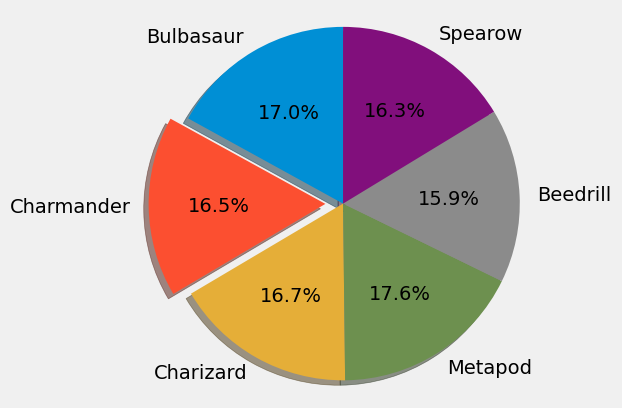

In [7]:
# 生成資料點，包含類別名、資料點、區塊各自和圓心的距離
labels = 'Bulbasaur', 'Charmander', 'Charizard', 'Metapod', 'Beedrill', 'Spearow'
sizes = [318, 309, 312, 329, 298, 305]
explode = (0, 0.1, 0, 0, 0, 0)

fig1, ax1 = plt.subplots()
# 繪製圓餅圖，sizes 資料點, autopct 百分比呈現的文字格式, startangle 起始角度=90度
ax1.pie(sizes, explode=explode, labels=labels, autopct='%1.1f%%',
        shadow=True, startangle=90)
# 將子圖的邊長都設成一樣，確保畫出來的圖是正圓形
ax1.axis('equal')
plt.show()


### 矩陣圖（熱點圖）
- 根據以下隨機生成的相關係數值，繪製矩陣圖

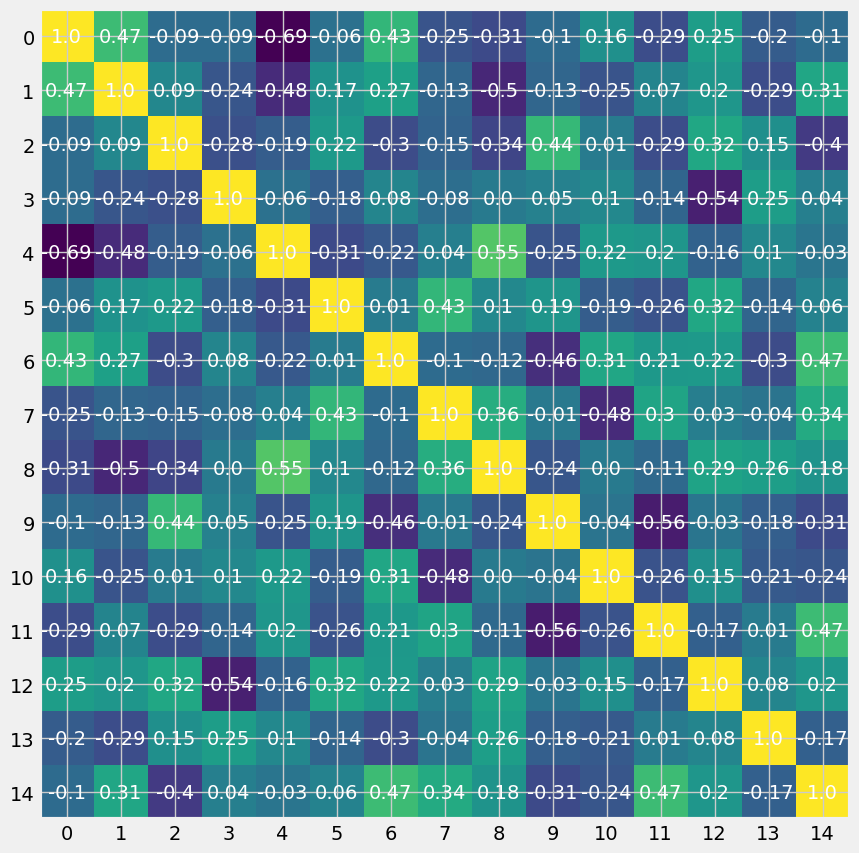

In [9]:
import pandas as pd

# 生成隨機資料
df = pd.DataFrame(np.random.rand(15, 15))
# 計算欄位間相關係數
corr = df.corr().round(2)
# 創建畫板及子圖
fig, ax = plt.subplots(figsize=(10, 10))
# 繪製矩陣圖
ax.imshow(corr)
# 設置 x, y 軸刻度位置及名稱
plt.xticks(range(len(corr.columns)), corr.columns)
plt.yticks(range(len(corr.columns)), corr.columns)
# 使用 ax.text 遍歷各個位置，標上相關係數數值
for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        text = ax.text(j, i, corr.values[i, j],
               ha='center', va='center', color='w')
plt.show()